[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WCC-Engineering/ENGR240/blob/main/Class%20Demos%20and%20Activities/Week%202/worksheet2_template.ipynb)

# Worksheet 2.2: Flow Regime Analysis

## ENGR& 240: Engineering Computations
### Introduction to Scientific Computing with Python

## Objectives
- Practice implementing conditional statements in Python
- Develop functions with decision logic
- Use lambda functions for simple formula evaluations
- Visualize the relationship between different engineering variables

## Instructions

In this worksheet, we will analyze fluid flow in pipes, focusing on determining flow regimes and calculating friction factors. These calculations are fundamental in fluid mechanics and are used extensively in designing pipe systems, analyzing pressure drops, and understanding fluid behavior.

We'll work with the Reynolds number, a dimensionless quantity that helps predict whether fluid flow will be laminar or turbulent. Based on the flow regime, we'll implement different equations for calculating the friction factor, which is used to determine pressure drop in pipe systems.

## Background: Reynolds Number and Flow Regimes

The Reynolds number (Re) is a dimensionless quantity that predicts flow patterns in fluid mechanics. It is defined as:

$$Re = \frac{\rho v D}{\mu} = \frac{v D}{\nu}$$

Where:
- $\rho$ is the fluid density (kg/m³)
- $v$ is the flow velocity (m/s)
- $D$ is the pipe diameter (m)
- $\mu$ is the dynamic viscosity (kg/(m·s))
- $\nu$ is the kinematic viscosity (m²/s), where $\nu = \mu/\rho$

Based on the Reynolds number, flow can be categorized into three regimes:
1. **Laminar flow**: Re < 2300
2. **Transitional flow**: 2300 ≤ Re ≤ 4000
3. **Turbulent flow**: Re > 4000

### Friction Factor Calculations

The Darcy friction factor (f) is used to calculate pressure drop in pipe flow and depends on the flow regime:

1. **Laminar flow**:
   $$f = \frac{64}{Re}$$

2. **Transitional flow**: Typically interpolated between laminar and turbulent values

3. **Turbulent flow**: Several equations exist, including the Colebrook equation and its approximations. For smooth pipes, the Blasius equation is often used:
   $$f = \frac{0.316}{Re^{0.25}}$$

For rough pipes in turbulent flow, we use the Haaland equation (an approximation of the Colebrook equation):
$$f = \left(-1.8 \log_{10}\left[\frac{6.9}{Re} + \left(\frac{\epsilon/D}{3.7}\right)^{1.11}\right]\right)^{-2}$$

Where:
- $\epsilon$ is the pipe roughness (m)
- $D$ is the pipe diameter (m)
- $\epsilon/D$ is the relative roughness

## Part 1: Reynolds Number Calculation

First, we'll write a function to calculate the Reynolds number. Let's import the necessary libraries and define our function.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_reynolds(velocity, diameter, kinematic_viscosity):
    """
    Calculate the Reynolds number for pipe flow.

    Parameters:
    ----------
    velocity : float or array
        Flow velocity in m/s
    diameter : float or array
        Pipe diameter in m
    kinematic_viscosity : float or array
        Kinematic viscosity in m²/s

    Returns:
    -------
    reynolds : float or array
        Reynolds number (dimensionless)
    """
    reynolds = velocity * diameter / kinematic_viscosity
    return reynolds

# Test the function
# Example: Water at 20°C (kinematic viscosity ≈ 1.004e-6 m²/s)
# Pipe diameter: 0.05 m (50 mm)
# Flow velocity: 1 m/s
water_viscosity = 1.004e-6  # m²/s
pipe_diameter = 0.05  # m
flow_velocity = 1.0  # m/s

re = calculate_reynolds(flow_velocity, pipe_diameter, water_viscosity)
print(f"Reynolds number: {re:.0f}")

Reynolds number: 49801


## Part 2: Classifying Flow Regimes

Now, let's write a function that classifies the flow regime based on the Reynolds number. Complete the function below to return the flow regime and apply it to the previous example.

In [3]:
"""
Laminar flow: Re < 2300
Transitional flow: 2300 ≤ Re ≤ 4000
Turbulent flow: Re > 4000
"""
def classify_flow_regime(reynolds):
    """
    Classify the flow regime based on the Reynolds number.

    Parameters:
    ----------
    reynolds : float or array
        Reynolds number

    Returns:
    -------
    regime : str or array of str
        Flow regime ('laminar', 'transitional', or 'turbulent')
    """
    # Your code here - use if/elif/else statements to classify the flow regime
    # based on the Reynolds number thresholds described in the background section
    if reynolds < 2300:
      regime='laminar'
    elif 2300 <= reynolds <= 4000:
      regime='transitional'
    elif reynolds > 4000:
      regime='turbulent'
    else:
      raise ValueError
    return regime

# Test the function with our previous example
flow_type = classify_flow_regime(re)
print(f"Flow regime: {flow_type}")

Flow regime: turbulent


Let's test our functions with a few different flow velocities to see how the Reynolds number and flow regime change:

In [4]:
# Calculate the Reynolds number and flow regime for the different velocities
velocities = [0.01, 0.05, 3.0]  # m/s

for velocity in velocities:
    reynolds = calculate_reynolds(velocity, pipe_diameter, water_viscosity)
    regime = classify_flow_regime(reynolds)
    print(f"Velocity: {velocity} m/s, Reynolds: {reynolds:.0f}, Regime: {regime}")

Velocity: 0.01 m/s, Reynolds: 498, Regime: laminar
Velocity: 0.05 m/s, Reynolds: 2490, Regime: transitional
Velocity: 3.0 m/s, Reynolds: 149402, Regime: turbulent


## Part 3: Friction Factor Calculation

Next, we'll implement a function to calculate the Darcy friction factor based on the flow regime and pipe properties. This function will use conditional statements to apply the appropriate equation for each flow regime.

For this implementation, we'll use:
- The theoretical equation (64/Re) for laminar flow
- Linear interpolation between laminar and turbulent values for transitional flow
- The Haaland equation for turbulent flow

In [5]:
def calculate_friction_factor(reynolds, relative_roughness=0):
    """
    Calculate the Darcy friction factor based on Reynolds number and relative roughness.

    Parameters:
    ----------
    reynolds : float or array
        Reynolds number
    relative_roughness : float or array, optional
        Relative pipe roughness (ε/D), dimensionless
        Default is 0 (smooth pipe)

    Returns:
    -------
    friction_factor : float or array
        Darcy friction factor
    """
    # Define the friction factor equations as lambda functions
    # This is a good use case for lambda functions - simple one-line formulas
    laminar_f = lambda re: 64 / re

    # Blasius equation for turbulent flow in smooth pipes
    blasius_f = lambda re: 0.316 / (re ** 0.25)

    # Haaland equation for turbulent flow in rough pipes
    haaland_f = lambda re, roughness: (-1.8 * np.log10((6.9/re) + (roughness/3.7)**1.11))**(-2)

    # Implement conditional logic based on flow regime
    # For the transitional regime, we'll use linear interpolation between the laminar and turbulent values
    # Linear interpolation formula: y = y1 + (x - x1) * (y2 - y1) / (x2 - x1)
    # Where: x1 = 2300, x2 = 4000, y1 = f_laminar, y2 = f_turbulent


    regime =  classify_flow_regime(reynolds)
    f_laminar = laminar_f(reynolds)
    f_blasius = blasius_f(reynolds)
    f_haaland = haaland_f(reynolds, relative_roughness)

    if relative_roughness == 0:
      if regime == 'laminar':
        friction_factor = f_laminar
      elif regime == 'turbulent':
        friction_factor = f_blasius
      elif regime == 'transitional':
        friction_factor = laminar_f(2300) + (reynolds - 2300) * (blasius_f(4000)-laminar_f(2300)) / (4000 - 2300)
    else:
      if regime == 'turbulent':
        friction_factor = f_haaland
      elif regime == 'transitional':
        friction_factor = laminar_f(2300) + (reynolds - 2300) * (haaland_f(4000)-laminar_f(2300)) / (4000 - 2300)
      else: friction_factor = f_laminar


    # For transitional flow, use this linear interpolation approach:
    # 1. Calculate f_laminar at Re = 2300
    # 2. Calculate f_turbulent at Re = 4000 (using haaland_f if roughness > 0, otherwise blasius_f)
    # 3. Calculate interpolation factor t = (reynolds - 2300) / (4000 - 2300)
    # 4. Calculate friction_factor = f_laminar + t * (f_turbulent - f_laminar)

    return friction_factor

# Test the function for our previous example with a typical roughness
relative_roughness = 0.0001  # A typical value for commercial steel pipes
f = calculate_friction_factor(re, relative_roughness)
print(f"Friction factor: {f:.6f}")

Friction factor: 0.021013


## Part 4: Pressure Drop Calculation

Now that we can calculate the friction factor, let's create a function to calculate the pressure drop in a pipe. The pressure drop is given by the Darcy-Weisbach equation:

$$\Delta P = f \cdot \frac{L}{D} \cdot \frac{\rho v^2}{2}$$

Where:
- $\Delta P$ is the pressure drop (Pa)
- $f$ is the Darcy friction factor (dimensionless)
- $L$ is the pipe length (m)
- $D$ is the pipe diameter (m)
- $\rho$ is the fluid density (kg/m³)
- $v$ is the flow velocity (m/s)

In [6]:
def calculate_pressure_drop(friction_factor, length, diameter, density, velocity):
    """
    Calculate pressure drop in a pipe using the Darcy-Weisbach equation.

    Parameters:
    ----------
    friction_factor : float or array
        Darcy friction factor
    length : float or array
        Pipe length in m
    diameter : float or array
        Pipe diameter in m
    density : float or array
        Fluid density in kg/m³
    velocity : float or array
        Flow velocity in m/s

    Returns:
    -------
    pressure_drop : float or array
        Pressure drop in Pa
    """
    Darcy_W = lambda f, L, D, rho, v: f*(L/D)*(rho*v**2)/2
    pressure_drop = Darcy_W(friction_factor, length, diameter, density, velocity)

    return pressure_drop

# Test the function
water_density = 998.2  # kg/m³ at 20°C
pipe_length = 100  # m

pressure_drop = calculate_pressure_drop(f, pipe_length, pipe_diameter, water_density, flow_velocity)
print(f"Pressure drop: {pressure_drop:.2f} Pa ({pressure_drop/1000:.4f} kPa)")

Pressure drop: 20974.91 Pa (20.9749 kPa)


## Part 5: Visualizing the Relationship Between Velocity and Pressure Drop

Finally, let's visualize the relationship between flow velocity and pressure drop. We'll create a plot that shows how the pressure drop changes with velocity, highlighting the transition between flow regimes.

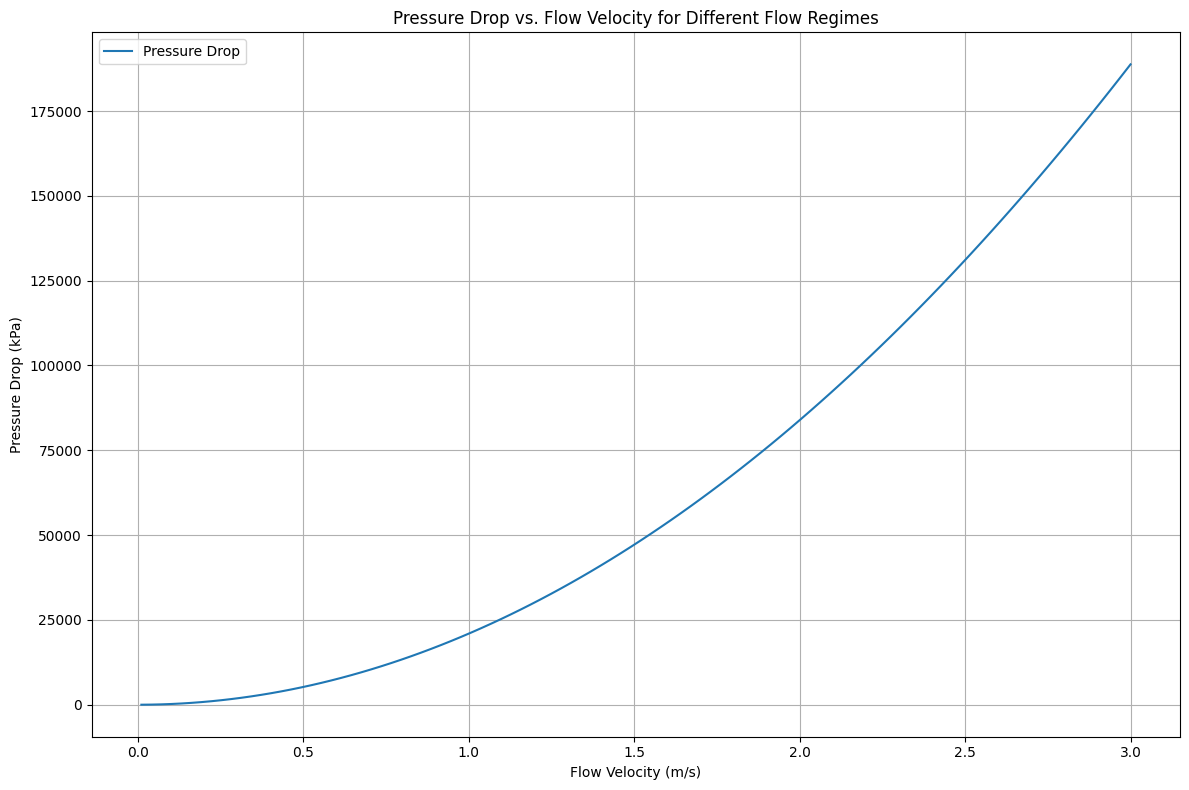

In [8]:
# Create a range of velocities
velocities = np.linspace(0.01, 3.0, 100)  # m/s

# Calculate the pressure drop for each velocity
# Your code here - use a loop or vectorization to calculate pressure drop for each velocity
# Store the results along with the Reynolds numbers and flow regimes
pressure_drop_values = calculate_pressure_drop(f, pipe_length, pipe_diameter, water_density, velocities)

# Plot the results
plt.figure(figsize=(12, 8))

# Create a plot of pressure drop vs. velocity with different colors for each flow regime
# Your code here

#Change the y-axis scale to logarithmic for a more informative figure

plt.xlabel('Flow Velocity (m/s)')
plt.ylabel('Pressure Drop (kPa)')
plt.title('Pressure Drop vs. Flow Velocity for Different Flow Regimes')
plt.plot(velocities, pressure_drop_values, label="Pressure Drop")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Reflection

After completing this worksheet, answer the following questions:

1. How do conditional statements help you model different physical phenomena in engineering problems?
* Often times in engineering applications, we simplify properties of a system that are within a certain threshold that allows us to approximate the behvior.

2. What are the benefits of breaking down a complex analysis into separate functions vs. having one large function that does everything?
* This approach simplifies troubleshooting, allows for more opportunites to extract information, and more closely approximate the behavior of a non-continuous function.

3. How would you modify the code to handle a different fluid or pipe material? What changes would be needed?
* You could add an argument to pass whichever fluid or pipe material that would reference a materials & properties table for the associated values.

4. How did using lambda functions for mathematical formulas improve (or not improve) your code's readability and maintainability?
* lambda functions are a powerful way to emulate mathematical functions in a compact, single line.